# Inventory constraint evaluation

This notebook evaluates whether the equipment recommended by the **literature-grounded RAG system** can be matched to the local equipment inventory database.

The main metrics follow the thesis methodology:

- **Inventory Hit Rate**: fraction of queries for which at least one recommended equipment item can be matched to the database.
- **Average inventory hits**: average number of matched recommendations per query.
- **Inventory fraction**: fraction of recommended equipment items that can be linked to the inventory.
- **Average relevance of matched items**: average RAG relevance score of the recommendations that were matched to the database.

The notebook also reports stricter and diagnostic metrics, such as exact-only match rates, top-1/top-3 inventory hit rates, query-type breakdowns, and match-type distributions.


In [1]:
import json
import re
import sqlite3
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

OUTPUT_DIR = Path("data/evaluation/inventory_constraint")
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("inventory_constraint")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR

PosixPath('inventory_constraint')

## 1. Configure input paths

The notebook first tries the expected repository paths. If those are not available, it falls back to the uploaded files in `/mnt/data`.


In [3]:
def first_existing_path(candidates: list[str | Path]) -> Path:
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(
        "None of the candidate paths exist:\n"
        + "\n".join(str(Path(c)) for c in candidates)
    )


RAG_OUTPUT_PATH = first_existing_path([
    "../data/processed/test_problem_answer_output.jsonl",
    "../mnt/data/test_problem_answer_output.jsonl",
])

DB_PATH = first_existing_path([
    "../data/processed/equipment_inventory.sqlite",
    "../mnt/data/equipment_inventory.sqlite",
])

print("RAG output:", RAG_OUTPUT_PATH)
print("Inventory DB:", DB_PATH)

RAG output: ../data/processed/test_problem_answer_output.jsonl
Inventory DB: ../data/processed/equipment_inventory.sqlite


## 2. Load the RAG output and inspect the inventory database

In [4]:
def read_jsonl(path: str | Path) -> list[dict[str, Any]]:
    records = []
    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


rag_records = read_jsonl(RAG_OUTPUT_PATH)

print(f"Loaded {len(rag_records)} RAG records")

run_status_counts = pd.Series(
    [record.get("run_status", "unknown") for record in rag_records]
).value_counts(dropna=False)

display(run_status_counts.to_frame("n_records"))

Loaded 578 RAG records


,n_records
completed,578


In [5]:
with sqlite3.connect(DB_PATH) as connection:
    db_tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
        connection,
    )

    inventory_db_summary = []
    for table_name in ["equipment", "equipment_aliases", "equipment_mentions"]:
        if table_name in set(db_tables["name"]):
            n_rows = pd.read_sql_query(
                f"SELECT COUNT(*) AS n FROM {table_name}",
                connection,
            )["n"].iloc[0]
            inventory_db_summary.append({
                "table": table_name,
                "n_rows": int(n_rows),
            })

inventory_db_summary_df = pd.DataFrame(inventory_db_summary)

display(inventory_db_summary_df)

,table,n_rows
0,equipment,2141
1,equipment_aliases,5970
2,equipment_mentions,2852


## 3. Load the inventory matching function

The notebook uses the existing `find_equipment_matches` function from `equipment_recommender_rag.equipment_inventory`. If that import is unavailable, a fallback implementation with the same exact/partial normalized-name logic is defined inside the notebook.


In [6]:
import sys


def find_repository_root(start: Path | None = None) -> Path | None:
    """
    Find the repository root that should be added to sys.path.

    This is needed when the notebook is run from:
    equipment_recommender_rag/notebooks/

    while the package lives in:
    equipment_recommender_rag/equipment_recommender_rag/
    """
    start = (start or Path.cwd()).resolve()

    for parent in [start, *start.parents]:
        # Most common case: parent is the repository root.
        package_file = (
            parent
            / "equipment_recommender_rag"
            / "equipment_inventory"
            / "equipment_database.py"
        )
        if package_file.exists():
            return parent

        # Backup case: parent is one level above the repository root.
        nested_package_file = (
            parent
            / "equipment_recommender_rag"
            / "equipment_recommender_rag"
            / "equipment_inventory"
            / "equipment_database.py"
        )
        if nested_package_file.exists():
            return parent / "equipment_recommender_rag"

    return None


repository_root = find_repository_root()

if repository_root is not None:
    repository_root_string = str(repository_root)
    if repository_root_string not in sys.path:
        sys.path.insert(0, repository_root_string)
    print(f"Added repository root to sys.path: {repository_root}")
else:
    print("Could not automatically find repository root. Trying import anyway.")

try:
    from equipment_recommender_rag.equipment_inventory.equipment_database import (
        find_equipment_matches,
        normalize_text,
    )
    print("Using matcher from equipment_recommender_rag.equipment_inventory.equipment_database")

except Exception as import_error:
    print("Could not import project matcher. Using notebook fallback implementation.")
    print("Import error:", repr(import_error))

    def normalize_text(value: Any) -> str:
        if value is None or pd.isna(value):
            return ""

        text = str(value).lower()
        text = text.replace("–", "-").replace("—", "-")
        text = text.replace("_", " ").replace("-", " ")
        text = re.sub(r"[^a-z0-9µμ/+. ]+", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def find_equipment_matches(
        equipment_name: str,
        aliases: list[str] | None = None,
        db_path: str | Path = DB_PATH,
        limit: int = 10,
    ) -> list[dict[str, Any]]:
        aliases = aliases or []
        search_terms = [equipment_name] + aliases
        normalized_terms = [
            normalize_text(term)
            for term in search_terms
            if normalize_text(term)
        ]

        if not normalized_terms:
            return []

        with sqlite3.connect(db_path) as connection:
            connection.row_factory = sqlite3.Row

            exact_rows = []
            seen_ids = set()

            for term in normalized_terms:
                rows = connection.execute(
                    """
                    SELECT DISTINCT
                        e.id,
                        e.canonical_name,
                        e.normalized_name,
                        e.manufacturer,
                        e.model,
                        e.equipment_type,
                        e.aliases_json,
                        e.mention_count,
                        e.primary_mention_count,
                        e.supporting_mention_count,
                        e.average_confidence_score,
                        'exact' AS match_type
                    FROM equipment e
                    LEFT JOIN equipment_aliases a ON a.equipment_id = e.id
                    WHERE e.normalized_name = ?
                       OR a.normalized_alias = ?
                    ORDER BY e.mention_count DESC
                    """,
                    (term, term),
                ).fetchall()

                for row in rows:
                    if row["id"] not in seen_ids:
                        exact_rows.append(row)
                        seen_ids.add(row["id"])

            partial_rows = []
            if len(exact_rows) < limit:
                for term in normalized_terms:
                    pattern = f"%{term}%"
                    rows = connection.execute(
                        """
                        SELECT DISTINCT
                            e.id,
                            e.canonical_name,
                            e.normalized_name,
                            e.manufacturer,
                            e.model,
                            e.equipment_type,
                            e.aliases_json,
                            e.mention_count,
                            e.primary_mention_count,
                            e.supporting_mention_count,
                            e.average_confidence_score,
                            'partial' AS match_type
                        FROM equipment e
                        LEFT JOIN equipment_aliases a ON a.equipment_id = e.id
                        WHERE e.normalized_name LIKE ?
                           OR a.normalized_alias LIKE ?
                           OR ? LIKE '%' || e.normalized_name || '%'
                           OR ? LIKE '%' || a.normalized_alias || '%'
                        ORDER BY e.mention_count DESC
                        """,
                        (pattern, pattern, term, term),
                    ).fetchall()

                    for row in rows:
                        if row["id"] not in seen_ids:
                            partial_rows.append(row)
                            seen_ids.add(row["id"])

            rows = (exact_rows + partial_rows)[:limit]

        return [
            {
                "equipment_id": row["id"],
                "canonical_name": row["canonical_name"],
                "normalized_name": row["normalized_name"],
                "manufacturer": row["manufacturer"],
                "model": row["model"],
                "equipment_type": row["equipment_type"],
                "aliases": json.loads(row["aliases_json"] or "[]"),
                "mention_count": row["mention_count"],
                "primary_mention_count": row["primary_mention_count"],
                "supporting_mention_count": row["supporting_mention_count"],
                "average_confidence_score": row["average_confidence_score"],
                "match_type": row["match_type"],
            }
            for row in rows
        ]

Added repository root to sys.path: /Users/Ippe/dev/thesisAI/equipment_recommender_rag
Using matcher from equipment_recommender_rag.equipment_inventory.equipment_database


## 4. Extract RAG recommendations

The inventory constraint is evaluated on the final `aggregated_equipment` output of the RAG system. Failed runs and queries with no returned equipment are retained at the query level and count as having no inventory match.


In [7]:
RELEVANCE_TO_SCORE = {
    "best_match": 3,
    "acceptable_alternative": 2,
    "acceptable_alternatives": 2,
    "supporting_but_not_ideal": 1,
    "clearly_not_suitable": 0,
}


def get_query_id(record: dict[str, Any]) -> str:
    return (
        record.get("input_query_id")
        or record.get("input_run_id")
        or record.get("original_query")
        or ""
    )


def get_query_type(record: dict[str, Any]) -> str | None:
    benchmark_item = record.get("input_raw_benchmark_item") or {}
    return benchmark_item.get("query_type")


def get_rag_items(record: dict[str, Any]) -> list[dict[str, Any]]:
    items = record.get("aggregated_equipment") or []
    extracted_items = []

    for rank, item in enumerate(items, start=1):
        equipment_name = (
            item.get("equipment_name")
            or item.get("normalized_equipment_name")
            or item.get("rag_equipment_name")
            or ""
        )

        aliases = item.get("aliases") or []
        if not isinstance(aliases, list):
            aliases = []

        relevance_label = (
            item.get("best_relevance_label")
            or item.get("relevance_label")
        )

        relevance_score = item.get("best_relevance_score")
        if relevance_score is None:
            relevance_score = RELEVANCE_TO_SCORE.get(relevance_label, np.nan)

        confidence_score = (
            item.get("max_confidence_score")
            or item.get("confidence_score")
        )

        extracted_items.append({
            "rank": rank,
            "rag_equipment_name": equipment_name,
            "rag_normalized_equipment_name": normalize_text(equipment_name),
            "rag_aliases": aliases,
            "rag_relevance_label": relevance_label,
            "rag_relevance_score": relevance_score,
            "rag_confidence_score": confidence_score,
            "rag_num_supporting_papers": item.get("num_supporting_papers"),
            "rag_num_supporting_subproblems": item.get("num_supporting_subproblems"),
        })

    return extracted_items


query_base_rows = []
item_base_rows = []

for record in rag_records:
    query_id = get_query_id(record)
    query_type = get_query_type(record)
    items = get_rag_items(record)

    query_base_rows.append({
        "query_id": query_id,
        "query_type": query_type,
        "original_query": record.get("original_query"),
        "run_status": record.get("run_status"),
        "source_is_review_paper": record.get("input_source_is_review_paper"),
        "num_returned_equipment": len(items),
        "has_returned_equipment": len(items) > 0,
    })

    for item in items:
        item_base_rows.append({
            "query_id": query_id,
            "query_type": query_type,
            "run_status": record.get("run_status"),
            "source_is_review_paper": record.get("input_source_is_review_paper"),
            **item,
        })


query_base_df = pd.DataFrame(query_base_rows)
item_base_df = pd.DataFrame(item_base_rows)

print("Query rows:", len(query_base_df))
print("Item rows:", len(item_base_df))

display(query_base_df.head())
display(item_base_df.head())

Query rows: 578
Item rows: 1680


,query_id,query_type,original_query,run_status,source_is_review_paper,num_returned_equipment,has_returned_equipment
0,antifouling_03,process_optimization,A coating shows good initial antifouling behavior but loses performance after scratching and repeated use. I need a ...,completed,True,3,True
1,polyester_thermal_mechanics,method_selection,"A new biobased polyester is being considered for PET-like bottles and fibers, but we need to know whether its therma...",completed,True,4,True
2,antifouling_02,method_selection,We need to evaluate a slippery fouling-release coating for marine use and check whether attached foulants can be rem...,completed,True,4,True
3,PEF_processing_crystallization,process_optimization,"During scale-up of a PEF bottle or film process, the material crystallizes too slowly and the final product is britt...",completed,True,5,True
4,redox_lipidomics,method_selection,"I need to identify specific oxidized phospholipid biomarkers of programmed cell death from cell or tissue samples, e...",completed,True,6,True


,query_id,query_type,run_status,source_is_review_paper,rank,rag_equipment_name,rag_normalized_equipment_name,rag_aliases,rag_relevance_label,rag_relevance_score,rag_confidence_score,rag_num_supporting_papers,rag_num_supporting_subproblems
0,antifouling_03,process_optimization,completed,True,1,scratch test setup,scratch test setup,"[scratch testing, scratch healing test]",best_match,3,0.93,2,1
1,antifouling_03,process_optimization,completed,True,2,mechanical testing system,mechanical testing system,"[mechanical property test, destructive test setup]",best_match,3,0.84,2,1
2,antifouling_03,process_optimization,completed,True,3,marine field test setup,marine field test setup,"[real marine field test, sea-based antifouling test]",acceptable_alternative,2,0.70,2,1
3,polyester_thermal_mechanics,method_selection,completed,True,1,Differential Scanning Calorimeter,differential scanning calorimeter,"[DSC, Differential Scanning Calorimetry instrument]",best_match,3,0.99,1,1
4,polyester_thermal_mechanics,method_selection,completed,True,2,Dynamic Mechanical Thermal Analyzer,dynamic mechanical thermal analyzer,"[DMA, Dynamic Mechanical Thermal Analysis instrument]",best_match,3,0.97,1,1


## 5. Match RAG recommendations to the local inventory

In [ ]:
MATCH_LIMIT_PER_ITEM = 5

match_cache: dict[tuple[str, tuple[str, ...]], list[dict[str, Any]]] = {}


def cached_find_equipment_matches(
    equipment_name: str,
    aliases: list[str],
    db_path: str | Path = DB_PATH,
    limit: int = MATCH_LIMIT_PER_ITEM,
) -> list[dict[str, Any]]:
    cache_key = (
        normalize_text(equipment_name),
        tuple(sorted(normalize_text(alias) for alias in aliases if normalize_text(alias))),
    )

    if cache_key not in match_cache:
        match_cache[cache_key] = find_equipment_matches(
            equipment_name=equipment_name,
            aliases=aliases,
            db_path=db_path,
            limit=limit,
        )

    return match_cache[cache_key]


matched_item_rows = []

for _, item_row in item_base_df.iterrows():
    matches = cached_find_equipment_matches(
        equipment_name=item_row["rag_equipment_name"],
        aliases=item_row["rag_aliases"],
        db_path=DB_PATH,
        limit=MATCH_LIMIT_PER_ITEM,
    )

    top_match = matches[0] if matches else {}

    exact_match_found = any(match.get("match_type") == "exact" for match in matches)
    partial_match_found = any(match.get("match_type") == "partial" for match in matches)

    matched_item_rows.append({
        **item_row.to_dict(),
        "database_match_found": bool(matches),
        "database_exact_match_found": exact_match_found,
        "database_partial_match_found": partial_match_found,
        "database_match_count": len(matches),
        "top_database_equipment_id": top_match.get("equipment_id") or top_match.get("id"),
        "top_database_name": top_match.get("canonical_name"),
        "top_database_match_type": top_match.get("match_type"),
        "top_database_equipment_type": top_match.get("equipment_type"),
        "top_database_mention_count": top_match.get("mention_count"),
        "top_database_primary_mention_count": top_match.get("primary_mention_count"),
        "top_database_supporting_mention_count": top_match.get("supporting_mention_count"),
        "top_database_avg_confidence": top_match.get("average_confidence_score"),
        "database_matches_json": json.dumps(matches, ensure_ascii=False),
    })


item_match_df = pd.DataFrame(matched_item_rows)

print("Matched item rows:", len(item_match_df))
print("Unique matching calls:", len(match_cache))

display(item_match_df.head(10))

Matched item rows: 1680
Unique matching calls: 1597


,query_id,query_type,run_status,source_is_review_paper,rank,rag_equipment_name,rag_normalized_equipment_name,rag_aliases,rag_relevance_label,rag_relevance_score,rag_confidence_score,rag_num_supporting_papers,rag_num_supporting_subproblems,database_match_found,database_exact_match_found,database_partial_match_found,database_match_count,top_database_equipment_id,top_database_name,top_database_match_type,top_database_equipment_type,top_database_mention_count,top_database_primary_mention_count,top_database_supporting_mention_count,top_database_avg_confidence,database_matches_json
0,antifouling_03,process_optimization,completed,True,1,scratch test setup,scratch test setup,"[scratch testing, scratch healing test]",best_match,3,0.93,2,1,True,False,True,3,703.0,crossed-beam setup,partial,beam experiment,2.0,2.0,0.0,0.985000,"[{""equipment_id"": 703, ""canonical_name"": ""crossed-beam setup"", ""manufacturer"": null, ""model"": null, ""equipment_type""..."
1,antifouling_03,process_optimization,completed,True,2,mechanical testing system,mechanical testing system,"[mechanical property test, destructive test setup]",best_match,3,0.84,2,1,True,False,True,5,7.0,transmission electron microscope,partial,microscopy,10.0,8.0,2.0,0.943000,"[{""equipment_id"": 7, ""canonical_name"": ""transmission electron microscope"", ""manufacturer"": null, ""model"": null, ""equ..."
2,antifouling_03,process_optimization,completed,True,3,marine field test setup,marine field test setup,"[real marine field test, sea-based antifouling test]",acceptable_alternative,2,0.70,2,1,True,False,True,3,703.0,crossed-beam setup,partial,beam experiment,2.0,2.0,0.0,0.985000,"[{""equipment_id"": 703, ""canonical_name"": ""crossed-beam setup"", ""manufacturer"": null, ""model"": null, ""equipment_type""..."
3,polyester_thermal_mechanics,method_selection,completed,True,1,Differential Scanning Calorimeter,differential scanning calorimeter,"[DSC, Differential Scanning Calorimetry instrument]",best_match,3,0.99,1,1,True,True,False,5,777.0,differential scanning calorimeter,exact,thermal analysis,5.0,5.0,0.0,0.986000,"[{""equipment_id"": 777, ""canonical_name"": ""differential scanning calorimeter"", ""manufacturer"": ""TA-Instruments"", ""mod..."
4,polyester_thermal_mechanics,method_selection,completed,True,2,Dynamic Mechanical Thermal Analyzer,dynamic mechanical thermal analyzer,"[DMA, Dynamic Mechanical Thermal Analysis instrument]",best_match,3,0.97,1,1,True,True,True,3,1542.0,dynamic mechanical analyzer,exact,mechanical testing,1.0,1.0,0.0,0.990000,"[{""equipment_id"": 1542, ""canonical_name"": ""dynamic mechanical analyzer"", ""manufacturer"": ""Anton Paar"", ""model"": ""702..."
5,polyester_thermal_mechanics,method_selection,completed,True,3,Tensile Testing Machine,tensile testing machine,"[tensile tester, universal testing machine, tensile testing]",acceptable_alternative,2,0.89,2,1,True,True,False,5,253.0,tensile testing machine,exact,mechanical testing,1.0,0.0,1.0,0.930000,"[{""equipment_id"": 253, ""canonical_name"": ""tensile testing machine"", ""manufacturer"": ""Instron GmbH"", ""model"": ""5940 s..."
6,polyester_thermal_mechanics,method_selection,completed,True,4,Optical Microscope,optical microscope,"[optical microscopy, in situ microscopy]",supporting_but_not_ideal,1,0.85,1,1,True,True,False,5,141.0,optical microscope,exact,imaging,14.0,0.0,14.0,0.871429,"[{""equipment_id"": 141, ""canonical_name"": ""optical microscope"", ""manufacturer"": null, ""model"": null, ""equipment_type""..."
7,antifouling_02,method_selection,completed,True,1,high-pressure water jet,high pressure water jet,"[water jet, high-pressure jet cleaning]",best_match,3,0.97,2,1,True,False,True,3,1246.0,electron tomography,partial,imaging,1.0,1.0,0.0,0.990000,"[{""equipment_id"": 1246, ""canonical_name"": ""electron tomography"", ""manufacturer"": null, ""model"": null, ""equipment_typ..."
8,antifouling_02,method_selection,completed,True,2,high-speed boat modified for hydrodynamic testing,high speed 

## Make output more strict
At some places there is too loose of an argument e.g. scratch test setup
crossed-beam setup. Or that aliases are the same for different things, 

In [10]:
GENERIC_MATCH_TOKENS = {
    "setup",
    "system",
    "instrument",
    "machine",
    "device",
    "equipment",
    "platform",
    "method",
    "test",
    "testing",
    "measurement",
    "measurements",
    "analysis",
    "assay",
    "tool",
    "apparatus",
}


def parse_aliases(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return []
    return []


def parse_matches(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return []
    return []


def informative_tokens(text: str) -> set[str]:
    tokens = normalize_text(text).split()
    return {
        token
        for token in tokens
        if len(token) >= 3 and token not in GENERIC_MATCH_TOKENS
    }


def is_strong_partial_match(rag_text: str, db_text: str) -> bool:
    """
    Decide whether a partial match is strong enough to count as inventory evidence.

    This rejects weak matches based only on words such as 'setup', 'system',
    'test', or short acronyms that occur inside unrelated words.
    """
    rag_norm = normalize_text(rag_text)
    db_norm = normalize_text(db_text)

    if not rag_norm or not db_norm:
        return False

    # Reject very short substring matches such as ET, TEM, AFM inside unrelated words
    if len(rag_norm) < 6 or len(db_norm) < 6:
        return False

    rag_tokens = informative_tokens(rag_norm)
    db_tokens = informative_tokens(db_norm)

    if not rag_tokens or not db_tokens:
        return False

    shared_tokens = rag_tokens.intersection(db_tokens)

    # Require at least two informative overlapping tokens
    if len(shared_tokens) < 2:
        return False

    overlap_ratio = len(shared_tokens) / min(len(rag_tokens), len(db_tokens))
    jaccard = len(shared_tokens) / len(rag_tokens.union(db_tokens))

    # Good phrase overlap, e.g. dynamic mechanical thermal analyzer
    # vs dynamic mechanical analyzer
    if rag_norm in db_norm or db_norm in rag_norm:
        return overlap_ratio >= 0.67

    # Otherwise require substantial token overlap
    return overlap_ratio >= 0.67 or jaccard >= 0.50


def get_strict_inventory_matches(row) -> list[dict]:
    """
    Keep exact matches and only strong partial matches.
    """
    rag_texts = [row["rag_equipment_name"]] + parse_aliases(row["rag_aliases"])
    matches = parse_matches(row["database_matches_json"])

    strict_matches = []

    for match in matches:
        db_texts = [match.get("canonical_name", "")] + match.get("aliases", [])

        # Original exact matches are reliable
        if match.get("match_type") == "exact":
            strict_matches.append({
                **match,
                "strict_match_type": "exact",
            })
            continue

        # Partial matches need additional filtering
        strong_partial = any(
            is_strong_partial_match(rag_text, db_text)
            for rag_text in rag_texts
            for db_text in db_texts
        )

        if strong_partial:
            strict_matches.append({
                **match,
                "strict_match_type": "strong_partial",
            })

    return strict_matches

In [11]:
strict_match_rows = []

for _, row in item_match_df.iterrows():
    strict_matches = get_strict_inventory_matches(row)
    top_strict_match = strict_matches[0] if strict_matches else {}

    strict_match_rows.append({
        "strict_database_match_found": bool(strict_matches),
        "strict_database_exact_match_found": any(
            match.get("strict_match_type") == "exact"
            for match in strict_matches
        ),
        "strict_database_partial_match_found": any(
            match.get("strict_match_type") == "strong_partial"
            for match in strict_matches
        ),
        "strict_database_match_count": len(strict_matches),
        "strict_top_database_equipment_id": top_strict_match.get("equipment_id"),
        "strict_top_database_name": top_strict_match.get("canonical_name"),
        "strict_top_database_match_type": top_strict_match.get("strict_match_type"),
        "strict_top_database_equipment_type": top_strict_match.get("equipment_type"),
        "strict_top_database_mention_count": top_strict_match.get("mention_count"),
        "strict_database_matches_json": json.dumps(
            strict_matches,
            ensure_ascii=False,
        ),
    })

strict_match_df = pd.DataFrame(strict_match_rows)

item_match_df = pd.concat(
    [
        item_match_df.reset_index(drop=True),
        strict_match_df.reset_index(drop=True),
    ],
    axis=1,
)

display(item_match_df.head(10))

,query_id,query_type,run_status,source_is_review_paper,rank,rag_equipment_name,rag_normalized_equipment_name,rag_aliases,rag_relevance_label,rag_relevance_score,rag_confidence_score,rag_num_supporting_papers,rag_num_supporting_subproblems,database_match_found,database_exact_match_found,database_partial_match_found,database_match_count,top_database_equipment_id,top_database_name,top_database_match_type,top_database_equipment_type,top_database_mention_count,top_database_primary_mention_count,top_database_supporting_mention_count,top_database_avg_confidence,database_matches_json,strict_database_match_found,strict_database_exact_match_found,strict_database_partial_match_found,strict_database_match_count,strict_top_database_equipment_id,strict_top_database_name,strict_top_database_match_type,strict_top_database_equipment_type,strict_top_database_mention_count,strict_database_matches_json
0,antifouling_03,process_optimization,completed,True,1,scratch test setup,scratch test setup,"[scratch testing, scratch healing test]",best_match,3,0.93,2,1,True,False,True,3,703.0,crossed-beam setup,partial,beam experiment,2.0,2.0,0.0,0.985000,"[{""equipment_id"": 703, ""canonical_name"": ""crossed-beam setup"", ""manufacturer"": null, ""model"": null, ""equipment_type""...",False,False,False,0,NaN,NaN,NaN,NaN,NaN,[]
1,antifouling_03,process_optimization,completed,True,2,mechanical testing system,mechanical testing system,"[mechanical property test, destructive test setup]",best_match,3,0.84,2,1,True,False,True,5,7.0,transmission electron microscope,partial,microscopy,10.0,8.0,2.0,0.943000,"[{""equipment_id"": 7, ""canonical_name"": ""transmission electron microscope"", ""manufacturer"": null, ""model"": null, ""equ...",False,False,False,0,NaN,NaN,NaN,NaN,NaN,[]
2,antifouling_03,process_optimization,completed,True,3,marine field test setup,marine field test setup,"[real marine field test, sea-based antifouling test]",acceptable_alternative,2,0.70,2,1,True,False,True,3,703.0,crossed-beam setup,partial,beam experiment,2.0,2.0,0.0,0.985000,"[{""equipment_id"": 703, ""canonical_name"": ""crossed-beam setup"", ""manufacturer"": null, ""model"": null, ""equipment_type""...",False,False,False,0,NaN,NaN,NaN,NaN,NaN,[]
3,polyester_thermal_mechanics,method_selection,completed,True,1,Differential Scanning Calorimeter,differential scanning calorimeter,"[DSC, Differential Scanning Calorimetry instrument]",best_match,3,0.99,1,1,True,True,False,5,777.0,differential scanning calorimeter,exact,thermal analysis,5.0,5.0,0.0,0.986000,"[{""equipment_id"": 777, ""canonical_name"": ""differential scanning calorimeter"", ""manufacturer"": ""TA-Instruments"", ""mod...",True,True,False,5,777.0,differential scanning calorimeter,exact,thermal analysis,5.0,"[{""equipment_id"": 777, ""canonical_name"": ""differential scanning calorimeter"", ""manufacturer"": ""TA-Instruments"", ""mod..."
4,polyester_thermal_mechanics,method_selection,completed,True,2,Dynamic Mechanical Thermal Analyzer,dynamic mechanical thermal analyzer,"[DMA, Dynamic Mechanical Thermal Analysis instrument]",best_match,3,0.97,1,1,True,True,True,3,1542.0,dynamic mechanical analyzer,exact,mechanical testing,1.0,1.0,0.0,0.990000,"[{""equipment_id"": 1542, ""canonical_name"": ""dynamic mechanical analyzer"", ""manufacturer"": ""Anton Paar"", ""model"": ""702...",True,True,False,1,1542.0,dynamic mechanical analyzer,exact,mechanical testing,1.0,"[{""equipment_id"": 1542, ""canonical_name"": ""dynamic mechanical analyzer"", ""manufacturer"": ""Anton Paar"", ""model"": ""702..."
5,polyester_thermal_mechanics,method_selection,completed,True,3,Tensile Testing Machine,tensile testing machine,"[tensile tester, universal testing machine, tensile testing]",acceptable_alternative,2,0.89,2,1,True,True,False,5,253.0,tensile testing machine,exact,mechanical testing,1.0,0.0,1.0,0.930000,"[{""equipment_id"": 253, ""canonical_name"": ""tensile testing machine"", ""manufacturer"": ""Instron GmbH"", ""model"": ""5940 s...",True,Tru

In [12]:
strict_item_level_summary_df = pd.DataFrame([{
    "n_recommended_items": len(item_match_df),

    "raw_item_match_rate": item_match_df["database_match_found"].mean(),
    "exact_item_match_rate": item_match_df["database_exact_match_found"].mean(),

    "strict_item_match_rate": item_match_df["strict_database_match_found"].mean(),
    "strict_exact_item_match_rate": item_match_df["strict_database_exact_match_found"].mean(),
    "strict_partial_item_match_rate": item_match_df["strict_database_partial_match_found"].mean(),

    "mean_relevance_raw_matched": item_match_df.loc[
        item_match_df["database_match_found"],
        "rag_relevance_score",
    ].mean(),

    "mean_relevance_strict_matched": item_match_df.loc[
        item_match_df["strict_database_match_found"],
        "rag_relevance_score",
    ].mean(),
}])

display(strict_item_level_summary_df.round(3))

,n_recommended_items,raw_item_match_rate,exact_item_match_rate,strict_item_match_rate,strict_exact_item_match_rate,strict_partial_item_match_rate,mean_relevance_raw_matched,mean_relevance_strict_matched
0,1680,0.985,0.543,0.667,0.543,0.219,2.28,2.343


## 6. Query-level inventory metrics

In [14]:
def safe_divide(numerator: float, denominator: float) -> float:
    if denominator == 0 or pd.isna(denominator):
        return np.nan
    return numerator / denominator


def summarize_query_inventory(group: pd.DataFrame) -> pd.Series:
    n_items = len(group)

    # Raw matches
    n_raw = int(group["database_match_found"].sum())
    n_exact = int(group["database_exact_match_found"].sum())
    n_partial = int(group["database_partial_match_found"].sum())

    # Strict matches
    n_strict = int(group["strict_database_match_found"].sum())
    n_strict_exact = int(group["strict_database_exact_match_found"].sum())
    n_strict_partial = int(group["strict_database_partial_match_found"].sum())

    # Relevant according to the RAG system itself
    relevant_group = group[group["rag_relevance_score"] >= 2]

    raw_matched_group = group[group["database_match_found"]]
    exact_group = group[group["database_exact_match_found"]]
    strict_group = group[group["strict_database_match_found"]]

    raw_matched_relevant_group = group[
        (group["database_match_found"])
        & (group["rag_relevance_score"] >= 2)
    ]

    strict_matched_relevant_group = group[
        (group["strict_database_match_found"])
        & (group["rag_relevance_score"] >= 2)
    ]

    return pd.Series({
        "num_returned_equipment_from_items": n_items,

        # Raw inventory metrics: useful as diagnostic, but too permissive
        "num_raw_inventory_hits": n_raw,
        "raw_inventory_hit": n_raw > 0,
        "raw_inventory_fraction": safe_divide(n_raw, n_items),
        "top1_raw_inventory_hit": bool(
            group.loc[group["rank"] <= 1, "database_match_found"].any()
        ),
        "top3_raw_inventory_hit": bool(
            group.loc[group["rank"] <= 3, "database_match_found"].any()
        ),

        # Exact inventory metrics: safest / most conservative
        "num_exact_inventory_hits": n_exact,
        "exact_inventory_hit": n_exact > 0,
        "exact_inventory_fraction": safe_divide(n_exact, n_items),
        "top1_exact_inventory_hit": bool(
            group.loc[group["rank"] <= 1, "database_exact_match_found"].any()
        ),
        "top3_exact_inventory_hit": bool(
            group.loc[group["rank"] <= 3, "database_exact_match_found"].any()
        ),

        # Raw partial count: diagnostic only
        "num_raw_partial_inventory_hits": n_partial,

        # Strict inventory metrics: recommended main metric
        "num_strict_inventory_hits": n_strict,
        "num_strict_exact_inventory_hits": n_strict_exact,
        "num_strict_partial_inventory_hits": n_strict_partial,
        "strict_inventory_hit": n_strict > 0,
        "strict_exact_inventory_hit": n_strict_exact > 0,
        "strict_partial_inventory_hit": n_strict_partial > 0,
        "strict_inventory_fraction": safe_divide(n_strict, n_items),
        "top1_strict_inventory_hit": bool(
            group.loc[group["rank"] <= 1, "strict_database_match_found"].any()
        ),
        "top3_strict_inventory_hit": bool(
            group.loc[group["rank"] <= 3, "strict_database_match_found"].any()
        ),

        # Relevant inventory metrics
        "num_relevant_returned_equipment": len(relevant_group),

        "num_raw_relevant_inventory_hits": len(raw_matched_relevant_group),
        "raw_relevant_inventory_hit": len(raw_matched_relevant_group) > 0,
        "raw_relevant_inventory_fraction": safe_divide(
            len(raw_matched_relevant_group),
            len(relevant_group),
        ),

        "num_strict_relevant_inventory_hits": len(strict_matched_relevant_group),
        "strict_relevant_inventory_hit": len(strict_matched_relevant_group) > 0,
        "strict_relevant_inventory_fraction": safe_divide(
            len(strict_matched_relevant_group),
            len(relevant_group),
        ),

        # Relevance of matched items
        "mean_relevance_score_all_returned": group["rag_relevance_score"].mean(),
        "mean_relevance_score_raw_inventory_hits": raw_matched_group["rag_relevance_score"].mean(),
        "mean_relevance_score_exact_hits": exact_group["rag_relevance_score"].mean(),
        "mean_relevance_score_strict_hits": strict_group["rag_relevance_score"].mean(),

        # Database evidence strength
        "mean_database_mention_count_raw_hits": raw_matched_group["top_database_mention_count"].mean(),
        "mean_database_primary_mention_count_raw_hits": raw_matched_group["top_database_primary_mention_count"].mean(),
        "mean_database_confidence_raw_hits": raw_matched_group["top_database_avg_confidence"].mean(),

        "mean_database_mention_count_strict_hits": strict_group["strict_top_database_mention_count"].mean(),
    })

In [15]:
if len(item_match_df) > 0:
    query_inventory_from_items_df = (
        item_match_df
        .groupby("query_id")
        .apply(summarize_query_inventory, include_groups=False)
        .reset_index()
    )
else:
    query_inventory_from_items_df = pd.DataFrame(columns=["query_id"])

query_inventory_df = query_base_df.merge(
    query_inventory_from_items_df,
    on="query_id",
    how="left",
)

In [20]:
zero_cols = [
    "num_returned_equipment_from_items",

    "num_raw_inventory_hits",
    "num_exact_inventory_hits",
    "num_raw_partial_inventory_hits",

    "num_strict_inventory_hits",
    "num_strict_exact_inventory_hits",
    "num_strict_partial_inventory_hits",

    "num_relevant_returned_equipment",
    "num_raw_relevant_inventory_hits",
    "num_strict_relevant_inventory_hits",
]

for col in zero_cols:
    if col in query_inventory_df.columns:
        query_inventory_df[col] = query_inventory_df[col].fillna(0).astype(int)


bool_cols = [
    "raw_inventory_hit",
    "exact_inventory_hit",
    "strict_inventory_hit",
    "strict_exact_inventory_hit",
    "strict_partial_inventory_hit",

    "top1_raw_inventory_hit",
    "top3_raw_inventory_hit",
    "top1_exact_inventory_hit",
    "top3_exact_inventory_hit",
    "top1_strict_inventory_hit",
    "top3_strict_inventory_hit",

    "raw_relevant_inventory_hit",
    "strict_relevant_inventory_hit",
]

for col in bool_cols:
    if col in query_inventory_df.columns:
        query_inventory_df[col] = query_inventory_df[col].fillna(False).astype(bool)


fraction_cols = [
    "raw_inventory_fraction",
    "exact_inventory_fraction",
    "strict_inventory_fraction",
    "raw_relevant_inventory_fraction",
    "strict_relevant_inventory_fraction",
]

for col in fraction_cols:
    if col in query_inventory_df.columns:
        query_inventory_df[col] = query_inventory_df[col].fillna(0.0)

display(query_inventory_df.head(20))
print("Query-level rows:", len(query_inventory_df))

,query_id,query_type,original_query,run_status,source_is_review_paper,num_returned_equipment,has_returned_equipment,num_returned_equipment_from_items,num_raw_inventory_hits,raw_inventory_hit,raw_inventory_fraction,top1_raw_inventory_hit,top3_raw_inventory_hit,num_exact_inventory_hits,exact_inventory_hit,exact_inventory_fraction,top1_exact_inventory_hit,top3_exact_inventory_hit,num_raw_partial_inventory_hits,num_strict_inventory_hits,num_strict_exact_inventory_hits,num_strict_partial_inventory_hits,strict_inventory_hit,strict_exact_inventory_hit,strict_partial_inventory_hit,strict_inventory_fraction,top1_strict_inventory_hit,top3_strict_inventory_hit,num_relevant_returned_equipment,num_raw_relevant_inventory_hits,raw_relevant_inventory_hit,raw_relevant_inventory_fraction,num_strict_relevant_inventory_hits,strict_relevant_inventory_hit,strict_relevant_inventory_fraction,mean_relevance_score_all_returned,mean_relevance_score_raw_inventory_hits,mean_relevance_score_exact_hits,mean_relevance_score_strict_hits,mean_database_mention_count_raw_hits,mean_database_primary_mention_count_raw_hits,mean_database_confidence_raw_hits,mean_database_mention_count_strict_hits
0,antifouling_03,process_optimization,A coating shows good initial antifouling behavior but loses performance after scratching and repeated use. I need a ...,completed,True,3,True,3,3,True,1.0,True,True,0,False,0.000000,False,False,3,0,0,0,False,False,False,0.000000,False,False,3,3,True,1.0,0,False,0.000000,2.666667,2.666667,NaN,NaN,4.666667,4.00,0.971000,NaN
1,polyester_thermal_mechanics,method_selection,"A new biobased polyester is being considered for PET-like bottles and fibers, but we need to know whether its therma...",completed,True,4,True,4,4,True,1.0,True,True,4,True,1.000000,True,True,1,4,4,0,True,True,False,1.000000,True,True,3,3,True,1.0,3,True,1.000000,2.250000,2.250000,2.250000,2.25,5.250000,1.50,0.944357,5.250000
2,antifouling_02,method_selection,We need to evaluate a slippery fouling-release coating for marine use and check whether attached foulants can be rem...,completed,True,4,True,4,4,True,1.0,True,True,0,False,0.000000,False,False,4,0,0,0,False,False,False,0.000000,False,False,4,4,True,1.0,0,False,0.000000,2.500000,2.500000,NaN,NaN,1.250000,1.00,0.976250,NaN
3,PEF_processing_crystallization,process_optimization,"During scale-up of a PEF bottle or film process, the material crystallizes too slowly and the final product is britt...",completed,True,5,True,5,5,True,1.0,True,True,3,True,0.600000,True,True,4,5,3,2,True,True,True,1.000000,True,True,4,4,True,1.0,4,True,1.000000,2.200000,2.200000,2.333333,2.20,4.400000,1.60,0.955486,4.400000
4,redox_lipidomics,method_selection,"I need to identify specific oxidized phospholipid biomarkers of programmed cell death from cell or tissue samples, e...",completed,True,6,True,6,6,True,1.0,True,True,1,True,0.166667,False,False,6,5,1,5,True,True,True,0.833333,False,True,4,4,True,1.0,3,True,0.750000,1.833333,1.833333,2.000000,1.60,4.333333,3.50,0.947333,2.000000
5,lipid_imaging,method_selection,"I need to map where phospholipids and their oxidation-related changes are located in tissue sections, ideally with b...",completed,True,5,True,5,5,True,1.0,True,True,0,False,0.000000,False,False,5,4,0,4,True,False,True,0.800000,True,True,4,4,True,1.0,3,True,0.750000,2.200000,2.200000,NaN,2.00,7.400000,4.40,0.934800,3.000000
6,ion_trap_cid_esI,specific,I need to reproduce the gas-phase fragmentation study of anionic cuprate complexes from solution and measure their c...,completed,False,2,True,2,2,True,1.0,True,True,0,False,0.000000,False,False,2,1,0,1,True,False,True,0.500000,True,True,1,1,True,1.0,1,True,1.000000,2.000000,2.000000,NaN,3.00,10.500000,6.00,0.946500,5.000000
7,fmi_analysis_display,process_optimization,I need a way to inspect and quantify fluorescence images so I can report target-to-background ratios and compare pro...,completed,True,5,True,5,5,True,1.0,True,True,0,False,0.000000,False,False,5,1,0,1,True,False,True,0.

Query-level rows: 578


In [17]:
inventory_by_query_type_df = (
    query_inventory_df
    .groupby("query_type")
    .agg(
        n_queries=("query_id", "nunique"),

        exact_inventory_hit_rate=("exact_inventory_hit", "mean"),
        strict_inventory_hit_rate=("strict_inventory_hit", "mean"),
        top1_strict_inventory_hit_rate=("top1_strict_inventory_hit", "mean"),
        top3_strict_inventory_hit_rate=("top3_strict_inventory_hit", "mean"),

        avg_exact_inventory_hits=("num_exact_inventory_hits", "mean"),
        avg_strict_inventory_hits=("num_strict_inventory_hits", "mean"),

        mean_exact_inventory_fraction=("exact_inventory_fraction", "mean"),
        mean_strict_inventory_fraction=("strict_inventory_fraction", "mean"),

        strict_relevant_inventory_hit_rate=("strict_relevant_inventory_hit", "mean"),
        mean_strict_relevant_inventory_fraction=("strict_relevant_inventory_fraction", "mean"),

        mean_relevance_score_strict_hits=("mean_relevance_score_strict_hits", "mean"),
    )
    .reset_index()
)

display(inventory_by_query_type_df.round(3))

,query_type,n_queries,exact_inventory_hit_rate,strict_inventory_hit_rate,top1_strict_inventory_hit_rate,top3_strict_inventory_hit_rate,avg_exact_inventory_hits,avg_strict_inventory_hits,mean_exact_inventory_fraction,mean_strict_inventory_fraction,strict_relevant_inventory_hit_rate,mean_strict_relevant_inventory_fraction,mean_relevance_score_strict_hits
0,broad_diagnostic,46,0.745,0.830,0.596,0.809,2.043,2.511,0.451,0.524,0.766,0.536,2.270
1,method_selection,75,0.680,0.733,0.493,0.707,1.267,1.667,0.401,0.500,0.693,0.506,2.298
2,process_optimization,21,0.714,0.810,0.619,0.714,1.476,2.000,0.404,0.530,0.714,0.521,2.257
3,specific,421,0.805,0.883,0.782,0.876,1.956,2.455,0.598,0.712,0.869,0.737,2.538


In [23]:
inventory_by_review_status_df = (
    query_inventory_df
    .groupby("source_is_review_paper")
    .agg(
        n_queries=("query_id", "nunique"),

        # Inventory hit rates
        exact_inventory_hit_rate=("exact_inventory_hit", "mean"),
        exact_inventory_hit_rate_std=("exact_inventory_hit", "std"),

        strict_inventory_hit_rate=("strict_inventory_hit", "mean"),
        strict_inventory_hit_rate_std=("strict_inventory_hit", "std"),

        top1_strict_inventory_hit_rate=("top1_strict_inventory_hit", "mean"),
        top1_strict_inventory_hit_rate_std=("top1_strict_inventory_hit", "std"),

        top3_strict_inventory_hit_rate=("top3_strict_inventory_hit", "mean"),
        top3_strict_inventory_hit_rate_std=("top3_strict_inventory_hit", "std"),

        # Number of inventory hits per query
        avg_exact_inventory_hits=("num_exact_inventory_hits", "mean"),
        std_exact_inventory_hits=("num_exact_inventory_hits", "std"),

        avg_strict_inventory_hits=("num_strict_inventory_hits", "mean"),
        std_strict_inventory_hits=("num_strict_inventory_hits", "std"),

        # Fraction of returned equipment that matched inventory
        mean_exact_inventory_fraction=("exact_inventory_fraction", "mean"),
        std_exact_inventory_fraction=("exact_inventory_fraction", "std"),

        mean_strict_inventory_fraction=("strict_inventory_fraction", "mean"),
        std_strict_inventory_fraction=("strict_inventory_fraction", "std"),

        # Relevant inventory matches
        strict_relevant_inventory_hit_rate=("strict_relevant_inventory_hit", "mean"),
        strict_relevant_inventory_hit_rate_std=("strict_relevant_inventory_hit", "std"),

        mean_strict_relevant_inventory_fraction=("strict_relevant_inventory_fraction", "mean"),
        std_strict_relevant_inventory_fraction=("strict_relevant_inventory_fraction", "std"),
    )
    .reset_index()
)

display(inventory_by_review_status_df.round(3))

,source_is_review_paper,n_queries,exact_inventory_hit_rate,exact_inventory_hit_rate_std,strict_inventory_hit_rate,strict_inventory_hit_rate_std,top1_strict_inventory_hit_rate,top1_strict_inventory_hit_rate_std,top3_strict_inventory_hit_rate,top3_strict_inventory_hit_rate_std,avg_exact_inventory_hits,std_exact_inventory_hits,avg_strict_inventory_hits,std_strict_inventory_hits,mean_exact_inventory_fraction,std_exact_inventory_fraction,mean_strict_inventory_fraction,std_strict_inventory_fraction,strict_relevant_inventory_hit_rate,strict_relevant_inventory_hit_rate_std,mean_strict_relevant_inventory_fraction,std_strict_relevant_inventory_fraction
0,False,421,0.805,0.397,0.883,0.322,0.782,0.414,0.876,0.330,1.956,2.300,2.455,3.097,0.598,0.383,0.712,0.345,0.869,0.338,0.737,0.355
1,True,141,0.706,0.457,0.776,0.418,0.545,0.500,0.741,0.439,1.552,1.685,1.993,2.118,0.417,0.357,0.512,0.374,0.720,0.450,0.518,0.396


In [19]:
inventory_by_query_type_df = (
    query_inventory_df
    .groupby("query_type")
    .agg(
        n_queries=("query_id", "nunique"),

        exact_inventory_hit_rate=("exact_inventory_hit", "mean"),
        strict_inventory_hit_rate=("strict_inventory_hit", "mean"),
        top1_strict_inventory_hit_rate=("top1_strict_inventory_hit", "mean"),
        top3_strict_inventory_hit_rate=("top3_strict_inventory_hit", "mean"),

        avg_exact_inventory_hits=("num_exact_inventory_hits", "mean"),
        avg_strict_inventory_hits=("num_strict_inventory_hits", "mean"),

        mean_exact_inventory_fraction=("exact_inventory_fraction", "mean"),
        mean_strict_inventory_fraction=("strict_inventory_fraction", "mean"),

        strict_relevant_inventory_hit_rate=("strict_relevant_inventory_hit", "mean"),
        mean_strict_relevant_inventory_fraction=("strict_relevant_inventory_fraction", "mean"),
    )
    .reset_index()
)

display(inventory_by_query_type_df.round(3))

,query_type,n_queries,exact_inventory_hit_rate,strict_inventory_hit_rate,top1_strict_inventory_hit_rate,top3_strict_inventory_hit_rate,avg_exact_inventory_hits,avg_strict_inventory_hits,mean_exact_inventory_fraction,mean_strict_inventory_fraction,strict_relevant_inventory_hit_rate,mean_strict_relevant_inventory_fraction
0,broad_diagnostic,46,0.745,0.830,0.596,0.809,2.043,2.511,0.451,0.524,0.766,0.536
1,method_selection,75,0.680,0.733,0.493,0.707,1.267,1.667,0.401,0.500,0.693,0.506
2,process_optimization,21,0.714,0.810,0.619,0.714,1.476,2.000,0.404,0.530,0.714,0.521
3,specific,421,0.805,0.883,0.782,0.876,1.956,2.455,0.598,0.712,0.869,0.737


## 7. Overall inventory-constraint results

The first table includes all RAG records. Failed runs and no-equipment outputs count as no inventory hit.


In [9]:
def inventory_overall_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "subset": label,
        "n_queries": df["query_id"].nunique(),
        "completed_queries": int((df["run_status"] == "completed").sum()),
        "equipment_return_rate": df["has_returned_equipment"].mean(),
        "avg_returned_equipment": df["num_returned_equipment"].mean(),
        "inventory_hit_rate": df["inventory_hit"].mean(),
        "exact_inventory_hit_rate": df["exact_inventory_hit"].mean(),
        "top1_inventory_hit_rate": df["top1_inventory_hit"].mean(),
        "top3_inventory_hit_rate": df["top3_inventory_hit"].mean(),
        "top1_exact_inventory_hit_rate": df["top1_exact_inventory_hit"].mean(),
        "top3_exact_inventory_hit_rate": df["top3_exact_inventory_hit"].mean(),
        "avg_inventory_hits": df["num_inventory_hits"].mean(),
        "avg_exact_inventory_hits": df["num_exact_inventory_hits"].mean(),
        "avg_inventory_fraction": df["inventory_fraction"].mean(),
        "avg_exact_inventory_fraction": df["exact_inventory_fraction"].mean(),
        "relevant_inventory_hit_rate": df["relevant_inventory_hit"].mean(),
        "avg_relevant_inventory_fraction": df["relevant_inventory_fraction"].mean(),
        "avg_relevance_score_inventory_hits": df["mean_relevance_score_inventory_hits"].mean(),
        "avg_relevance_score_exact_hits": df["mean_relevance_score_exact_hits"].mean(),
        "avg_database_mention_count_hits": df["mean_database_mention_count_hits"].mean(),
        "avg_database_primary_mention_count_hits": df["mean_database_primary_mention_count_hits"].mean(),
        "avg_database_confidence_hits": df["mean_database_confidence_hits"].mean(),
    }])


overall_inventory_summary_df = pd.concat(
    [
        inventory_overall_summary(query_inventory_df, "all_rag_records"),
        inventory_overall_summary(
            query_inventory_df[query_inventory_df["run_status"] == "completed"],
            "completed_only",
        ),
    ],
    ignore_index=True,
)

display(overall_inventory_summary_df.round(3))

overall_inventory_summary_df.to_csv(
    OUTPUT_DIR / "inventory_overall_summary.csv",
    index=False,
)

,subset,n_queries,completed_queries,equipment_return_rate,avg_returned_equipment,inventory_hit_rate,exact_inventory_hit_rate,top1_inventory_hit_rate,top3_inventory_hit_rate,top1_exact_inventory_hit_rate,top3_exact_inventory_hit_rate,avg_inventory_hits,avg_exact_inventory_hits,avg_inventory_fraction,avg_exact_inventory_fraction,relevant_inventory_hit_rate,avg_relevant_inventory_fraction,avg_relevance_score_inventory_hits,avg_relevance_score_exact_hits,avg_database_mention_count_hits,avg_database_primary_mention_count_hits,avg_database_confidence_hits
0,all_rag_records,561,578,0.965,2.907,0.962,0.78,0.96,0.962,0.6,0.758,3.49,1.856,0.955,0.553,0.96,0.958,2.431,2.471,5.002,3.223,0.96
1,completed_only,561,578,0.965,2.907,0.962,0.78,0.96,0.962,0.6,0.758,3.49,1.856,0.955,0.553,0.96,0.958,2.431,2.471,5.002,3.223,0.96


In [21]:
def parse_json_list(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return []
    return []


strict_partial_audit_df = item_match_df[
    (item_match_df["strict_database_partial_match_found"])
    & (~item_match_df["strict_database_exact_match_found"])
].copy()

strict_partial_audit_df = strict_partial_audit_df[
    [
        "query_id",
        "query_type",
        "source_is_review_paper",
        "rank",
        "rag_equipment_name",
        "rag_aliases",
        "rag_relevance_label",
        "rag_relevance_score",
        "strict_top_database_name",
        "strict_top_database_match_type",
        "strict_top_database_equipment_type",
        "strict_top_database_mention_count",
        "strict_database_matches_json",
    ]
].sort_values(
    by=["rag_relevance_score", "strict_top_database_mention_count"],
    ascending=[False, False],
)

display(strict_partial_audit_df.head(50))
print("Strict partial-only matches:", len(strict_partial_audit_df))

,query_id,query_type,source_is_review_paper,rank,rag_equipment_name,rag_aliases,rag_relevance_label,rag_relevance_score,strict_top_database_name,strict_top_database_match_type,strict_top_database_equipment_type,strict_top_database_mention_count,strict_database_matches_json
162,pld-hea-thinfilm-deposition,specific,False,1,pulsed laser deposition (PLD) system,"[PLD machine, pulsed laser deposition setup, laser ablation thin-film deposition system]",best_match,3,pulsed laser deposition system,strong_partial,fabrication,24.0,"[{""equipment_id"": 145, ""canonical_name"": ""pulsed laser deposition system"", ""manufacturer"": null, ""model"": null, ""equ..."
1437,skx_transport,process_optimization,True,1,lock-in amplifier-based Hall transport measurement setup,"[lock-in with non-perturbative current densities, Hall transport setup]",best_match,3,lock-in amplifier,strong_partial,electrical measurement,19.0,"[{""equipment_id"": 78, ""canonical_name"": ""lock-in amplifier"", ""manufacturer"": null, ""model"": null, ""equipment_type"": ..."
582,znalmg_in_situ_sem_tension,specific,False,1,in-situ scanning electron microscope with mechanical loading stage,"[in-situ SEM, SEM with in-situ loading platform, SEM coupled with real-time mechanical loading]",best_match,3,scanning electron microscope,strong_partial,microscopy,15.0,"[{""equipment_id"": 942, ""canonical_name"": ""scanning electron microscope"", ""manufacturer"": null, ""model"": null, ""equip..."
859,giwaxs_in_situ_sn_perovskite,specific,False,2,multimodal optical in situ spectroscopy spin coater system,"[home-built multimodal optical in situ measurements setup, optical in situ spin coater, multimodal optical in situ m...",best_match,3,spin coater,strong_partial,fabrication,15.0,"[{""equipment_id"": 286, ""canonical_name"": ""spin coater"", ""manufacturer"": null, ""model"": null, ""equipment_type"": ""fabr..."
12,PEF_processing_crystallization,process_optimization,True,2,Optical microscope with temperature-controlled heating stage,"[hot stage microscope, in-situ optical microscopy, optical microscopy on a hot stage]",best_match,3,optical microscope,strong_partial,imaging,14.0,"[{""equipment_id"": 141, ""canonical_name"": ""optical microscope"", ""manufacturer"": null, ""model"": null, ""equipment_type""..."
715,2des_psii_supercomplex,specific,False,1,cryogenic optical microscope for single-pixel excitation-emission spectroscopy,"[cryogenic optical microscope, single-pixel excitation-emission spectroscopy microscope, cryogenic temperature-compa...",best_match,3,optical microscope,strong_partial,imaging,14.0,"[{""equipment_id"": 141, ""canonical_name"": ""optical microscope"", ""manufacturer"": null, ""model"": null, ""equipment_type""..."
1444,clsm_perovskite_heterogeneity,specific,False,1,magneto-optical microscope,[magneto-optical microscopy],best_match,3,optical microscope,strong_partial,imaging,14.0,"[{""equipment_id"": 141, ""canonical_name"": ""optical microscope"", ""manufacturer"": null, ""model"": null, ""equipment_type""..."
782,afm_hsafm_membrane_domain_dissolution,specific,False,2,solid-state deuterium nuclear magnetic resonance spectrometer,"[solid-state 2H-NMR, 2H NMR]",best_match,3,nuclear magnetic resonance spectrometer,strong_partial,spectroscopy,13.0,"[{""equipment_id"": 10, ""canonical_name"": ""nuclear magnetic resonance spectrometer"", ""manufacturer"": null, ""model"": nu..."
1625,ssnmr_hydrogel_structure_dynamics,broad_diagnostic,True,2,13C CP/MAS NMR spectrometer,"[13C cross polarization magic angle spinning NMR, 13C CP/MAS NMR, CP/MAS NMR]",best_match,3,nuclear magnetic resonance spectrometer,strong_partial,spectroscopy,13.0,"[{""equipment_id"": 10, ""canonical_name"": ""nuclear magnetic resonance spectrometer"", ""manufacturer"": null, ""model"": nu..."
976,fasni3_xtal_phase_transition_xrd,specific,False,1,temperature-controlled single-crystal X-ray diffractometer,"[variable-temperature single-crystal X-ray diffraction setup, synchrotron X-ray single-crysta

Strict partial-only matches: 209


## 8. Results by query type and source-paper type

In [22]:
def inventory_group_summary(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    summary = (
        df
        .groupby(group_cols, dropna=False)
        .agg(
            n_queries=("query_id", "nunique"),
            completed_queries=("run_status", lambda s: int((s == "completed").sum())),
            equipment_return_rate=("has_returned_equipment", "mean"),
            avg_returned_equipment=("num_returned_equipment", "mean"),
            inventory_hit_rate=("inventory_hit", "mean"),
            exact_inventory_hit_rate=("exact_inventory_hit", "mean"),
            top3_inventory_hit_rate=("top3_inventory_hit", "mean"),
            top3_exact_inventory_hit_rate=("top3_exact_inventory_hit", "mean"),
            avg_inventory_hits=("num_inventory_hits", "mean"),
            avg_inventory_fraction=("inventory_fraction", "mean"),
            avg_exact_inventory_fraction=("exact_inventory_fraction", "mean"),
            relevant_inventory_hit_rate=("relevant_inventory_hit", "mean"),
            avg_relevance_score_inventory_hits=("mean_relevance_score_inventory_hits", "mean"),
            avg_database_mention_count_hits=("mean_database_mention_count_hits", "mean"),
        )
        .reset_index()
    )
    return summary


inventory_by_query_type_df = inventory_group_summary(
    query_inventory_df,
    ["query_type"],
)

inventory_by_source_type_df = inventory_group_summary(
    query_inventory_df,
    ["source_is_review_paper"],
)

inventory_by_query_and_source_type_df = inventory_group_summary(
    query_inventory_df,
    ["query_type", "source_is_review_paper"],
)

display(inventory_by_query_type_df.round(3))
display(inventory_by_source_type_df.round(3))
display(inventory_by_query_and_source_type_df.round(3))

inventory_by_query_type_df.to_csv(
    OUTPUT_DIR / "inventory_by_query_type.csv",
    index=False,
)

inventory_by_source_type_df.to_csv(
    OUTPUT_DIR / "inventory_by_source_type.csv",
    index=False,
)

inventory_by_query_and_source_type_df.to_csv(
    OUTPUT_DIR / "inventory_by_query_and_source_type.csv",
    index=False,
)

KeyError: "Label(s) ['inventory_fraction', 'inventory_hit', 'mean_database_mention_count_hits', 'mean_relevance_score_inventory_hits', 'num_inventory_hits', 'relevant_inventory_hit', 'top3_inventory_hit'] do not exist"

## 9. Item-level diagnostics

These tables inspect what kinds of RAG recommendations match the database. The exact/partial distinction is useful because partial string matching can be more permissive than exact normalized-name or alias matching.


In [11]:
item_level_summary_df = pd.DataFrame([{
    "n_recommended_items": len(item_match_df),
    "item_inventory_match_rate": item_match_df["database_match_found"].mean(),
    "item_exact_match_rate": item_match_df["database_exact_match_found"].mean(),
    "item_partial_match_rate": item_match_df["database_partial_match_found"].mean(),
    "mean_relevance_all_items": item_match_df["rag_relevance_score"].mean(),
    "mean_relevance_matched_items": item_match_df.loc[
        item_match_df["database_match_found"],
        "rag_relevance_score",
    ].mean(),
    "mean_relevance_unmatched_items": item_match_df.loc[
        ~item_match_df["database_match_found"],
        "rag_relevance_score",
    ].mean(),
    "mean_database_mention_count_matched": item_match_df.loc[
        item_match_df["database_match_found"],
        "top_database_mention_count",
    ].mean(),
}])

display(item_level_summary_df.round(3))

match_type_counts_df = (
    item_match_df
    .assign(
        match_type=item_match_df["top_database_match_type"].fillna("no_match")
    )
    .groupby("match_type")
    .agg(
        n_items=("rag_equipment_name", "count"),
        mean_relevance_score=("rag_relevance_score", "mean"),
    )
    .reset_index()
)

match_type_counts_df["item_fraction"] = (
    match_type_counts_df["n_items"] / match_type_counts_df["n_items"].sum()
)

display(match_type_counts_df.round(3))

item_level_summary_df.to_csv(
    OUTPUT_DIR / "inventory_item_level_summary.csv",
    index=False,
)

match_type_counts_df.to_csv(
    OUTPUT_DIR / "inventory_match_type_counts.csv",
    index=False,
)

,n_recommended_items,item_inventory_match_rate,item_exact_match_rate,item_partial_match_rate,mean_relevance_all_items,mean_relevance_matched_items,mean_relevance_unmatched_items,mean_database_mention_count_matched
0,1680,0.985,0.543,0.74,2.267,2.28,1.4,5.141


,match_type,n_items,mean_relevance_score,item_fraction
0,exact,912,2.352,0.543
1,no_match,25,1.400,0.015
2,partial,743,2.191,0.442


In [12]:
top_matched_database_equipment_df = (
    item_match_df[item_match_df["database_match_found"]]
    .groupby([
        "top_database_equipment_id",
        "top_database_name",
        "top_database_match_type",
        "top_database_equipment_type",
    ], dropna=False)
    .agg(
        n_rag_recommendations=("rag_equipment_name", "count"),
        n_queries=("query_id", "nunique"),
        mean_rag_relevance_score=("rag_relevance_score", "mean"),
        database_mention_count=("top_database_mention_count", "max"),
        database_primary_mention_count=("top_database_primary_mention_count", "max"),
    )
    .reset_index()
    .sort_values(
        ["n_queries", "n_rag_recommendations", "database_mention_count"],
        ascending=False,
    )
)

top_unmatched_rag_equipment_df = (
    item_match_df[~item_match_df["database_match_found"]]
    .groupby(["rag_equipment_name", "rag_relevance_label"], dropna=False)
    .agg(
        n_recommendations=("query_id", "count"),
        n_queries=("query_id", "nunique"),
        mean_rag_relevance_score=("rag_relevance_score", "mean"),
    )
    .reset_index()
    .sort_values(["n_queries", "n_recommendations"], ascending=False)
)

display(top_matched_database_equipment_df.head(20))
display(top_unmatched_rag_equipment_df.head(20))

top_matched_database_equipment_df.to_csv(
    OUTPUT_DIR / "top_matched_database_equipment.csv",
    index=False,
)

top_unmatched_rag_equipment_df.to_csv(
    OUTPUT_DIR / "top_unmatched_rag_equipment.csv",
    index=False,
)

,top_database_equipment_id,top_database_name,top_database_match_type,top_database_equipment_type,n_rag_recommendations,n_queries,mean_rag_relevance_score,database_mention_count,database_primary_mention_count
5,7.0,transmission electron microscope,partial,microscopy,129,107,2.155039,10.0,8.0
237,703.0,crossed-beam setup,partial,beam experiment,105,86,2.380952,2.0,2.0
52,87.0,ring oscillator,partial,oscillator,61,53,1.868852,1.0,0.0
68,141.0,optical microscope,partial,imaging,65,46,2.076923,14.0,0.0
242,710.0,photoluminescence spectroscopy setup,partial,spectroscopy,51,45,2.294118,5.0,5.0
94,183.0,optical tweezers,partial,manipulation system,43,41,2.162791,2.0,2.0
2,6.0,atomic force microscope,exact,microscopy,28,28,2.000000,34.0,12.0
14,19.0,spectroscopic ellipsometer,partial,spectroscopy,33,27,2.121212,1.0,1.0
104,205.0,spectrometer,partial,spectroscopy,28,25,2.642857,5.0,2.0
61,116.0,potentiostat / electrochemical cell electrodes,partial,other,18,16,2.222222,1.0,0.0


,rag_equipment_name,rag_relevance_label,n_recommendations,n_queries,mean_rag_relevance_score
0,Alpine cutting mill,supporting_but_not_ideal,1,1,1.0
1,Data logger,acceptable_alternative,1,1,2.0
2,GPU copy engines,acceptable_alternative,1,1,2.0
3,Gwyddion,supporting_but_not_ideal,1,1,1.0
4,Hall bar device,best_match,1,1,3.0
5,Hall bar structure,supporting_but_not_ideal,1,1,1.0
6,Intel oneMKL,supporting_but_not_ideal,1,1,1.0
7,NVIDIA cuBLAS,best_match,1,1,3.0
8,NVIDIA cuSolver,acceptable_alternative,1,1,2.0
9,NVLink,supporting_but_not_ideal,1,1,1.0


## 10. Plots

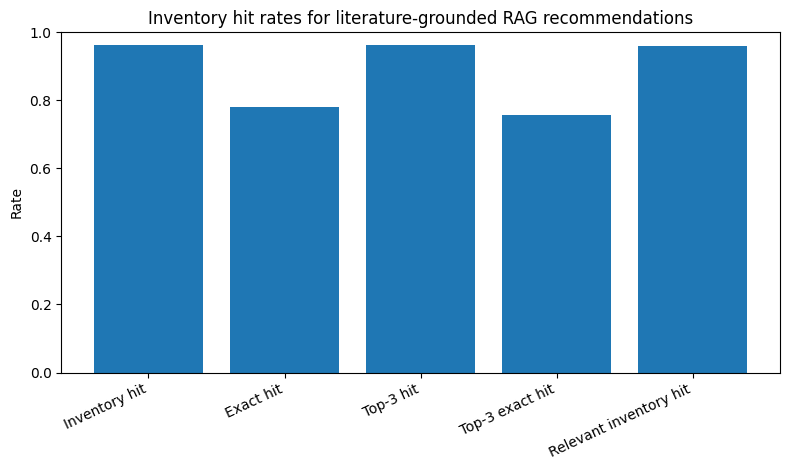

In [13]:
# Main inventory metrics

plot_overall = overall_inventory_summary_df[
    overall_inventory_summary_df["subset"] == "all_rag_records"
].iloc[0]

plot_metrics = {
    "Inventory hit": plot_overall["inventory_hit_rate"],
    "Exact hit": plot_overall["exact_inventory_hit_rate"],
    "Top-3 hit": plot_overall["top3_inventory_hit_rate"],
    "Top-3 exact hit": plot_overall["top3_exact_inventory_hit_rate"],
    "Relevant inventory hit": plot_overall["relevant_inventory_hit_rate"],
}

plt.figure(figsize=(8, 4.8))
plt.bar(list(plot_metrics.keys()), list(plot_metrics.values()))
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.title("Inventory hit rates for literature-grounded RAG recommendations")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

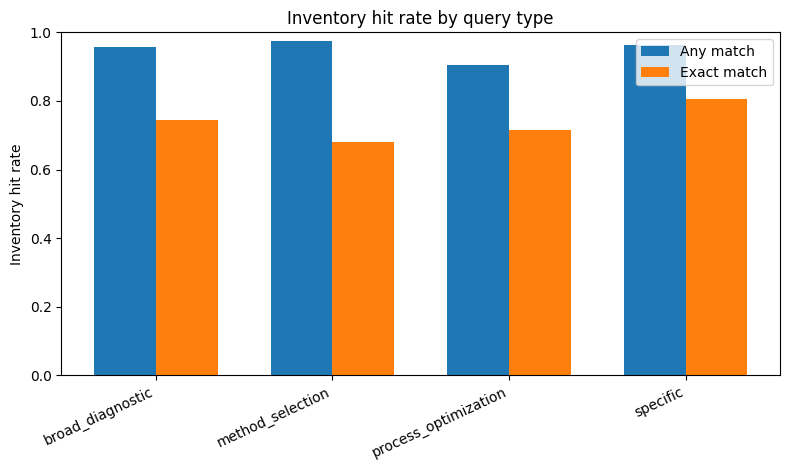

In [14]:
# Inventory hit rate by query type

plot_df = inventory_by_query_type_df.sort_values("query_type").copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(8, 4.8))
plt.bar(
    x - width / 2,
    plot_df["inventory_hit_rate"],
    width,
    label="Any match",
)
plt.bar(
    x + width / 2,
    plot_df["exact_inventory_hit_rate"],
    width,
    label="Exact match",
)

plt.xticks(x, plot_df["query_type"], rotation=25, ha="right")
plt.ylabel("Inventory hit rate")
plt.ylim(0, 1)
plt.title("Inventory hit rate by query type")
plt.legend()
plt.tight_layout()
plt.show()

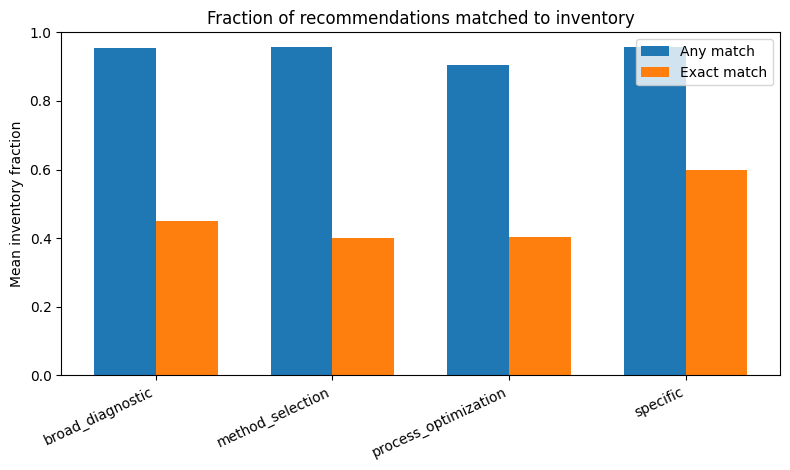

In [15]:
# Inventory fraction by query type

plot_df = inventory_by_query_type_df.sort_values("query_type").copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(8, 4.8))
plt.bar(
    x - width / 2,
    plot_df["avg_inventory_fraction"],
    width,
    label="Any match",
)
plt.bar(
    x + width / 2,
    plot_df["avg_exact_inventory_fraction"],
    width,
    label="Exact match",
)

plt.xticks(x, plot_df["query_type"], rotation=25, ha="right")
plt.ylabel("Mean inventory fraction")
plt.ylim(0, 1)
plt.title("Fraction of recommendations matched to inventory")
plt.legend()
plt.tight_layout()
plt.show()

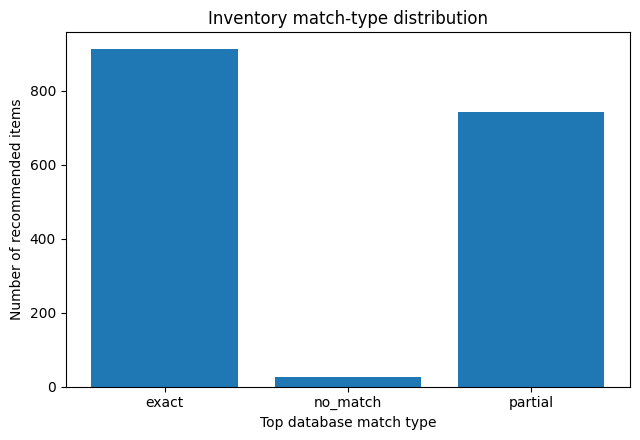

,match_type,n_items,mean_relevance_score,item_fraction
0,exact,912,2.352,0.543
1,no_match,25,1.400,0.015
2,partial,743,2.191,0.442


In [16]:
# Match-type distribution among recommended equipment items

plot_df = match_type_counts_df.copy()

plt.figure(figsize=(6.5, 4.5))
plt.bar(plot_df["match_type"], plot_df["n_items"])
plt.xlabel("Top database match type")
plt.ylabel("Number of recommended items")
plt.title("Inventory match-type distribution")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

## 11. Export full matched outputs

The item-level file contains one row per recommended equipment item. The query-level file contains one row per original RAG query.


In [17]:
item_match_df.to_csv(
    OUTPUT_DIR / "inventory_item_matches.csv",
    index=False,
)

query_inventory_df.to_csv(
    OUTPUT_DIR / "inventory_query_metrics.csv",
    index=False,
)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: /home/oai/inventory_constraint


## 12. Suggested thesis tables

For the main thesis text, the most compact outputs are usually:

1. `inventory_overall_summary.csv`
2. `inventory_by_query_type.csv`
3. `inventory_by_source_type.csv`

The item-level diagnostics are useful for checking whether the matching is too permissive, especially the difference between exact and partial matches.
